In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score	
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

C:\Users\TRIDEV PAL\Downloads\anacondajupiter\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\TRIDEV PAL\Downloads\anacondajupiter\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
print(np.__version__)
print(pd.__version__)

1.26.4
3.0.0


In [3]:
# !pip install --upgrade numpy pandas matplotlib

In [3]:
df = pd.read_csv(r"C:\Users\TRIDEV PAL\Documents\Capstone project\flipkart_mens_topwear_1000_records.csv")

In [4]:
df.head()

,name,company,price,original_price,discount,offers,size,url,page
0,Men Solid Zip Neck Cotton Blend Black T-Shirt,KAJARU,₹ 298,₹ 999,70% off,Hot Deal,NaN,https://www.flipkart.com/kajaru-solid-men-zip-...,1
1,"Men Printed Polo Neck Cotton Blend Black, Grey...",TRIPR,₹ 338,₹ 999,66% off,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-printed-men-pol...,1
2,Pack of 4 Men Solid Round Neck Cotton Blend Mu...,TRIPR,₹ 459,"₹ 1,999",77% off,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-solid-men-round...,1
3,"Men Striped Zip Neck Cotton Blend Black, White...",Try This,₹ 306,₹ 999,69% off,Only few left,NaN,https://www.flipkart.com/try-striped-men-zip-n...,1
4,Men Solid Henley Neck Cotton Blend Black T-Shirt,TRIPR,₹ 192,"₹ 1,999",90% off,Hot Deal,NaN,https://www.flipkart.com/tripr-solid-men-henle...,1


In [5]:
df.isnull().sum()

name                 0
company              0
price                0
original_price       6
discount             9
offers              49
size              1000
url                  0
page                 0
dtype: int64

In [6]:
df.shape

(1000, 9)

In [7]:
df.columns

Index(['name', 'company', 'price', 'original_price', 'discount', 'offers',
       'size', 'url', 'page'],
      dtype='str')

In [8]:
df.dtypes

name                  str
company               str
price                 str
original_price        str
discount              str
offers                str
size              float64
url                   str
page                int64
dtype: object

In [9]:
df.info

<bound method DataFrame.info of                                                   name      company  price  \
0        Men Solid Zip Neck Cotton Blend Black T-Shirt       KAJARU  ₹ 298   
1    Men Printed Polo Neck Cotton Blend Black, Grey...        TRIPR  ₹ 338   
2    Pack of 4 Men Solid Round Neck Cotton Blend Mu...        TRIPR  ₹ 459   
3    Men Striped Zip Neck Cotton Blend Black, White...     Try This  ₹ 306   
4     Men Solid Henley Neck Cotton Blend Black T-Shirt        TRIPR  ₹ 192   
..                                                 ...          ...    ...   
995      Men Solid Polo Neck Cotton Blend Blue T-Shirt     CANTABIL  ₹ 390   
996  Men Striped Round Neck Polyester Grey, White T...        Force  ₹ 243   
997  Men Regular Fit Checkered Button Down Collar C...     RED TAPE  ₹ 629   
998  Men's Tshirt Men Printed, Typography Round Nec...    BlueFicus  ₹ 325   
999   Men Regular Fit Solid Curved Collar Formal Shirt  youth first  ₹ 206   

    original_price discount    

In [10]:
df.describe()

,size,page
count,0.0,1000.000000
mean,NaN,13.000000
std,NaN,7.214711
min,NaN,1.000000
25%,NaN,7.000000
50%,NaN,13.000000
75%,NaN,19.000000
max,NaN,25.000000


## PHASE 2 : DATA CLEANING & PREPROCESSING

In [11]:
df.columns

Index(['name', 'company', 'price', 'original_price', 'discount', 'offers',
       'size', 'url', 'page'],
      dtype='str')

In [12]:
df['price'] = (
    df['price']
    .str.replace(r'[^\d.]', '', regex=True)
    .astype(float)
)

In [13]:
df['original_price'] = (
    df['original_price']
    .str.replace(r'[^\d.]', '', regex=True)
    .astype(float)
)

In [14]:
df['original_price'] = pd.to_numeric(
    df['original_price'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

In [15]:
df['discount'] = (
    df['discount']
    .str.extract(r'(\d+)')
    .astype(float)
)

In [16]:
df.head()

,name,company,price,original_price,discount,offers,size,url,page
0,Men Solid Zip Neck Cotton Blend Black T-Shirt,KAJARU,298.0,999.0,70.0,Hot Deal,NaN,https://www.flipkart.com/kajaru-solid-men-zip-...,1
1,"Men Printed Polo Neck Cotton Blend Black, Grey...",TRIPR,338.0,999.0,66.0,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-printed-men-pol...,1
2,Pack of 4 Men Solid Round Neck Cotton Blend Mu...,TRIPR,459.0,1999.0,77.0,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-solid-men-round...,1
3,"Men Striped Zip Neck Cotton Blend Black, White...",Try This,306.0,999.0,69.0,Only few left,NaN,https://www.flipkart.com/try-striped-men-zip-n...,1
4,Men Solid Henley Neck Cotton Blend Black T-Shirt,TRIPR,192.0,1999.0,90.0,Hot Deal,NaN,https://www.flipkart.com/tripr-solid-men-henle...,1


In [17]:
df.isnull().sum()

name                 0
company              0
price                0
original_price       6
discount             9
offers              49
size              1000
url                  0
page                 0
dtype: int64

In [18]:
df['original_price'] = df['original_price'].fillna(df['original_price'].median())

In [19]:
df['discount'] = df['discount'].fillna(0)

In [20]:
df['offers'] = df['offers'].fillna("No Offer")

In [21]:
df.isnull().sum()

name                 0
company              0
price                0
original_price       0
discount             0
offers               0
size              1000
url                  0
page                 0
dtype: int64

In [22]:
df.head()

,name,company,price,original_price,discount,offers,size,url,page
0,Men Solid Zip Neck Cotton Blend Black T-Shirt,KAJARU,298.0,999.0,70.0,Hot Deal,NaN,https://www.flipkart.com/kajaru-solid-men-zip-...,1
1,"Men Printed Polo Neck Cotton Blend Black, Grey...",TRIPR,338.0,999.0,66.0,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-printed-men-pol...,1
2,Pack of 4 Men Solid Round Neck Cotton Blend Mu...,TRIPR,459.0,1999.0,77.0,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-solid-men-round...,1
3,"Men Striped Zip Neck Cotton Blend Black, White...",Try This,306.0,999.0,69.0,Only few left,NaN,https://www.flipkart.com/try-striped-men-zip-n...,1
4,Men Solid Henley Neck Cotton Blend Black T-Shirt,TRIPR,192.0,1999.0,90.0,Hot Deal,NaN,https://www.flipkart.com/tripr-solid-men-henle...,1


In [23]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1000 non-null   str    
 1   company         1000 non-null   str    
 2   price           1000 non-null   float64
 3   original_price  1000 non-null   float64
 4   discount        1000 non-null   float64
 5   offers          1000 non-null   str    
 6   size            0 non-null      float64
 7   url             1000 non-null   str    
 8   page            1000 non-null   int64  
dtypes: float64(4), int64(1), str(4)
memory usage: 485.2 KB


,name,company,price,original_price,discount,offers,size,url,page
0,Men Solid Zip Neck Cotton Blend Black T-Shirt,KAJARU,298.0,999.0,70.0,Hot Deal,NaN,https://www.flipkart.com/kajaru-solid-men-zip-...,1
1,"Men Printed Polo Neck Cotton Blend Black, Grey...",TRIPR,338.0,999.0,66.0,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-printed-men-pol...,1
2,Pack of 4 Men Solid Round Neck Cotton Blend Mu...,TRIPR,459.0,1999.0,77.0,"Buy 2 items, save extra 5%",NaN,https://www.flipkart.com/tripr-solid-men-round...,1
3,"Men Striped Zip Neck Cotton Blend Black, White...",Try This,306.0,999.0,69.0,Only few left,NaN,https://www.flipkart.com/try-striped-men-zip-n...,1
4,Men Solid Henley Neck Cotton Blend Black T-Shirt,TRIPR,192.0,1999.0,90.0,Hot Deal,NaN,https://www.flipkart.com/tripr-solid-men-henle...,1


### • Create useful features (rating %, price band, category, etc.)

In [24]:
df['discount_pct'] = ((df['original_price'] - df['price']) / df['original_price']) * 100
df['discount_pct'] = df['discount_pct'].round(2)

In [25]:
df.discount_pct

0      70.17
1      66.17
2      77.04
3      69.37
4      90.40
       ...  
995    69.98
996    87.84
997    82.02
998    67.47
999    77.09
Name: discount_pct, Length: 1000, dtype: float64

In [26]:
df['savings'] = df['original_price'] - df['price']
df.savings

0       701.0
1       661.0
2      1540.0
3       693.0
4      1807.0
        ...  
995     909.0
996    1756.0
997    2870.0
998     674.0
999     693.0
Name: savings, Length: 1000, dtype: float64

In [27]:
def price_band(p):
    if p < 500:
        return "Budget"
    elif 1500 <= p:
        return "Mid-Range"
    else:
        return "Premium"

df['price_band'] = df['price'].apply(price_band)
df.price_band

0       Budget
1       Budget
2       Budget
3       Budget
4       Budget
        ...   
995     Budget
996     Budget
997    Premium
998     Budget
999     Budget
Name: price_band, Length: 1000, dtype: str

In [28]:
df.price_band.unique()

<ArrowStringArray>
['Budget', 'Premium']
Length: 2, dtype: str

In [29]:
df[df['price_band']=='Mid-Range']

,name,company,price,original_price,discount,offers,size,url,page,discount_pct,savings,price_band


In [30]:
df['high_discount'] = df['discount_pct'].apply(lambda x: 1 if x >= 50 else 0)
df.high_discount

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: high_discount, Length: 1000, dtype: int64

In [31]:
df.high_discount.unique()

array([1, 0], dtype=int64)

In [32]:
df[df['high_discount']== 0]

,name,company,price,original_price,discount,offers,size,url,page,discount_pct,savings,price_band,high_discount
25,Men Solid Round Neck Polyester Dark Blue T-Shirt,JOCKEY,998.0,999.0,0.0,Only few left,NaN,https://www.flipkart.com/jockey-solid-men-roun...,1,0.10,1.0,Premium,0
155,Men Solid Round Neck Polyester Dark Blue T-Shirt,JOCKEY,998.0,999.0,0.0,Only few left,NaN,https://www.flipkart.com/jockey-solid-men-roun...,4,0.10,1.0,Premium,0
173,Pack of 1 Pace Intellieaze Men Solid Crew Neck...,XYXX,399.0,469.0,14.0,Only few left,NaN,https://www.flipkart.com/xyxx-solid-men-crew-n...,5,14.93,70.0,Budget,0
258,Men Solid Polo Neck Pure Cotton White T-Shirt,LOUIS PHILIPPE,884.0,1499.0,41.0,Hot Deal,NaN,https://www.flipkart.com/louis-philippe-solid-...,7,41.03,615.0,Premium,0
303,Pack of 1 Pace Intellieaze Men Solid Crew Neck...,XYXX,399.0,449.0,11.0,No Offer,NaN,https://www.flipkart.com/xyxx-solid-men-crew-n...,8,11.14,50.0,Budget,0
453,Men Solid Polo Neck Polyester Grey T-Shirt,Maxzone,402.0,579.0,30.0,Hot Deal,NaN,https://www.flipkart.com/maxzone-solid-men-pol...,12,30.57,177.0,Budget,0
463,Men Slim Fit Checkered Formal Shirt,PARK AVENUE,883.0,1699.0,48.0,Hot Deal,NaN,https://www.flipkart.com/park-avenue-men-check...,12,48.03,816.0,Premium,0
485,Men Solid Zip Neck Polyester Green T-Shirt,TECHNOSPORT,478.0,559.0,14.0,No Offer,NaN,https://www.flipkart.com/technosport-solid-men...,13,14.49,81.0,Budget,0
535,Men Tailored Fit Solid Cut Away Collar Casual ...,U.S. POLO ASSN.,1139.0,1999.0,43.0,Hot Deal,NaN,https://www.flipkart.com/u-s-polo-assn-men-sol...,14,43.02,860.0,Premium,0
555,Men Solid Polo Neck Cotton Blend Blue T-Shirt,DUKE,649.0,999.0,35.0,No Offer,NaN,https://www.flipkart.com/duke-solid-men-polo-n...,14,35.04,350.0,Premium,0


In [33]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1000 non-null   str    
 1   company         1000 non-null   str    
 2   price           1000 non-null   float64
 3   original_price  1000 non-null   float64
 4   discount        1000 non-null   float64
 5   offers          1000 non-null   str    
 6   size            0 non-null      float64
 7   url             1000 non-null   str    
 8   page            1000 non-null   int64  
 9   discount_pct    1000 non-null   float64
 10  savings         1000 non-null   float64
 11  price_band      1000 non-null   str    
 12  high_discount   1000 non-null   int64  
dtypes: float64(6), int64(2), str(5)
memory usage: 522.4 KB


In [34]:
df.drop(columns=['size'], inplace=True)

In [35]:
df.columns

Index(['name', 'company', 'price', 'original_price', 'discount', 'offers',
       'url', 'page', 'discount_pct', 'savings', 'price_band',
       'high_discount'],
      dtype='str')

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1000 non-null   str    
 1   company         1000 non-null   str    
 2   price           1000 non-null   float64
 3   original_price  1000 non-null   float64
 4   discount        1000 non-null   float64
 5   offers          1000 non-null   str    
 6   url             1000 non-null   str    
 7   page            1000 non-null   int64  
 8   discount_pct    1000 non-null   float64
 9   savings         1000 non-null   float64
 10  price_band      1000 non-null   str    
 11  high_discount   1000 non-null   int64  
dtypes: float64(5), int64(2), str(5)
memory usage: 514.6 KB


### PHASE 3 : EXPLORATORY DATA ANALYSIS (EDA)

#### • Summary statistics (mean, median, spread)

In [37]:
df[['price', 'original_price', 'discount_pct', 'savings']].describe()

,price,original_price,discount_pct,savings
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,346.805000,1559.716000,75.275500,1212.911000
std,148.020522,659.137841,11.495377,608.322388
min,104.000000,351.000000,0.070000,1.000000
25%,246.000000,999.000000,69.470000,713.500000
50%,310.000000,1499.000000,76.240000,1130.000000
75%,406.500000,1999.000000,83.285000,1685.500000
max,1398.000000,4299.000000,93.090000,3547.000000


In [38]:
df['price'].mean()

346.805

In [39]:
df['price'].median()

310.0

In [40]:
df['price'].std()

148.02052239486946

In [41]:
df['price'].var()

21910.075050050047

In [42]:
df['price'].max() - df['price'].min()

1294.0

#### • Trend analysis (time, category, rating, price, etc.)

In [43]:
df.groupby('company')['price'].mean().sort_values(ascending=False)

company
Snitch             1398.000000
WROGN              1123.333333
U.S. POLO ASSN.    1064.000000
JOCKEY             1008.500000
LOUIS PHILIPPE      884.000000
                      ...     
Mundali             147.000000
PRABHU              142.000000
FUBACK              138.000000
Riva                112.000000
Axxitude            106.000000
Name: price, Length: 190, dtype: float64

In [44]:
df.company.unique()

<ArrowStringArray>
[                   'KAJARU',                     'TRIPR',
                  'Try This',                     'Surhi',
                    'VeBNoR',                   'N AND J',
                 'JACKBELLA',                     'DIMMY',
                   'Raymond',                     'WOXEN',
 ...
                 'Southcity',               'Tee Gallery',
                      'DBAX',                   'GLAUCUS',
 'United Colors of Benetton',                'BLUE SQUAD',
                'PrintHolic',                 'Lux Nitro',
                'hkCreation',                 'BlueFicus']
Length: 190, dtype: str

In [45]:
df.groupby('company')['discount_pct'].mean().sort_values(ascending=False)

company
FUBACK         93.090000
Surhi          89.490000
Smosh          89.440000
Voroxy         88.967500
HKV FASHION    88.831667
                 ...    
Maxzone        30.570000
Lux Nitro      17.090000
JOCKEY         16.060000
XYXX           13.666667
Snitch          0.070000
Name: discount_pct, Length: 190, dtype: float64

In [46]:
company_discount_pact = df.groupby('company')['discount_pct'].mean().sort_values(ascending=False)

In [47]:
df['company'].value_counts()

company
N AND J                      76
TRIPR                        69
METRONAUT                    50
VeBNoR                       40
RED TAPE                     39
                             ..
United Colors of Benetton     1
PrintHolic                    1
Lux Nitro                     1
hkCreation                    1
BlueFicus                     1
Name: count, Length: 190, dtype: int64

In [48]:
page_trend = df.groupby('page')[['price','discount_pct']].mean()
page_trend.head()

,price,discount_pct
page,,
1,333.675,76.64050
2,318.450,77.62675
3,322.375,76.12625
4,357.925,74.14900
5,316.625,75.94475


In [49]:
df['name'].value_counts().head(10)

name
Men Regular Fit Solid Casual Shirt                            50
Men Regular Fit Solid Spread Collar Casual Shirt              46
Men Slim Fit Self Design Spread Collar Casual Shirt           39
Men Regular Fit Solid Button Down Collar Casual Shirt         33
Men Regular Fit Solid Button Down Collar Formal Shirt         26
Pack of 4 Men Solid Round Neck Cotton Blend Multicolor ...    25
Men Solid Polo Neck Polyester Navy Blue T-Shirt               25
Pack of 3 Men Solid Round Neck Cotton Blend Multicolor ...    25
Pack of 4 Men Solid Round Neck Polyester Silver, Blue, ...    24
Men Solid Polo Neck Polyester Blue T-Shirt                    23
Name: count, dtype: int64

In [50]:
df.groupby('company')['savings'].mean().sort_values(ascending=False).head(10)

company
RED TAPE        3013.410256
Yazole          2287.250000
London Hills    2281.000000
Allen Cooper    2220.000000
Coofandy        2114.000000
InkTees         2107.000000
Helken          2107.000000
Think Tech      2080.000000
Voroxy          1956.500000
FUBACK          1858.000000
Name: savings, dtype: float64

In [51]:
company_savings = df.groupby('company')['savings'].mean().sort_values(ascending=False).head(10)

In [52]:
df['high_discount'].value_counts()

high_discount
1    980
0     20
Name: count, dtype: int64

In [53]:
df['price_band'].value_counts()

price_band
Budget     910
Premium     90
Name: count, dtype: int64

#### • Visualizations:

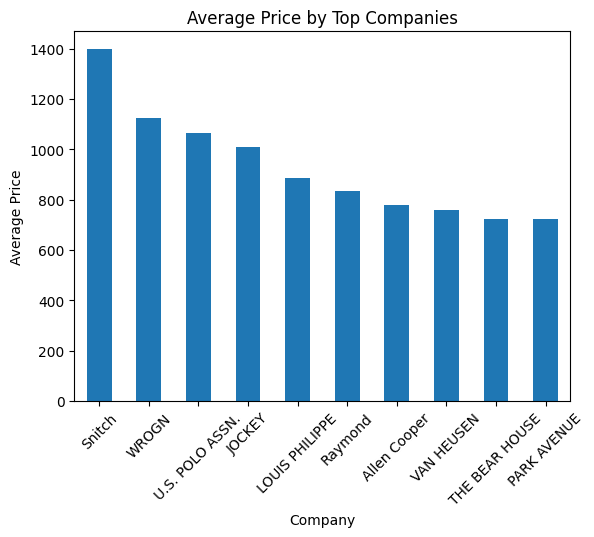

In [54]:
import matplotlib.pyplot as plt

top_companies = df.groupby('company')['price'].mean().sort_values(ascending=False).head(10)

plt.figure()
top_companies.plot(kind='bar')
plt.title("Average Price by Top Companies")
plt.xlabel("Company")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

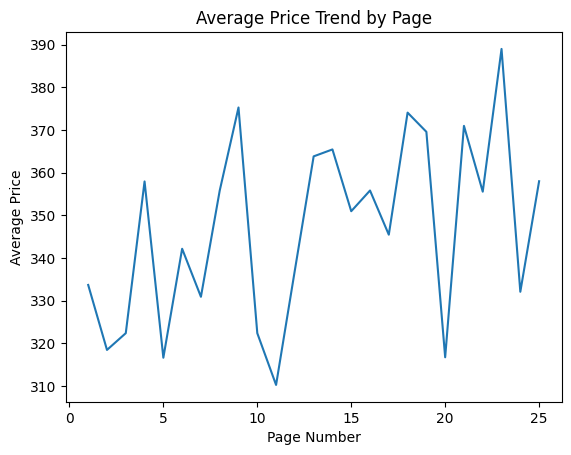

In [55]:
page_trend = df.groupby('page')['price'].mean()

plt.figure()
page_trend.plot(kind='line')
plt.title("Average Price Trend by Page")
plt.xlabel("Page Number")
plt.ylabel("Average Price")
plt.show()


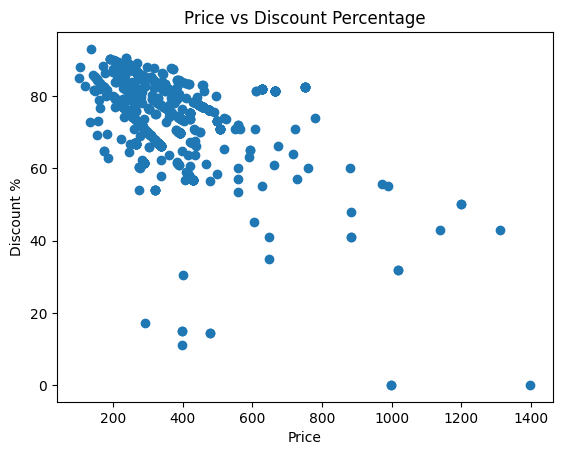

In [56]:
plt.figure()
plt.scatter(df['price'], df['discount_pct'])
plt.title("Price vs Discount Percentage")
plt.xlabel("Price")
plt.ylabel("Discount %")
plt.show()

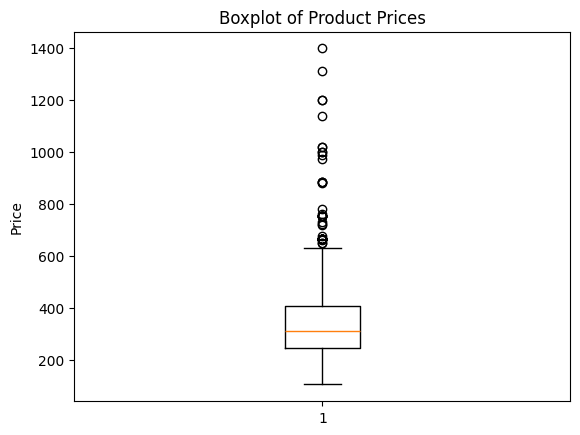

In [57]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['price'])
plt.title("Boxplot of Product Prices")
plt.ylabel("Price")
plt.show()

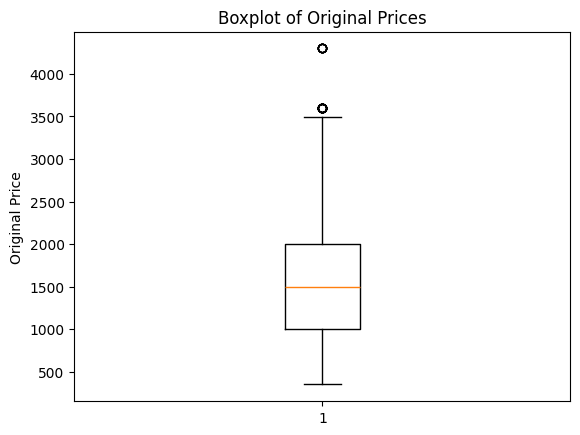

In [58]:
plt.figure()
plt.boxplot(df['original_price'])
plt.title("Boxplot of Original Prices")
plt.ylabel("Original Price")
plt.show()

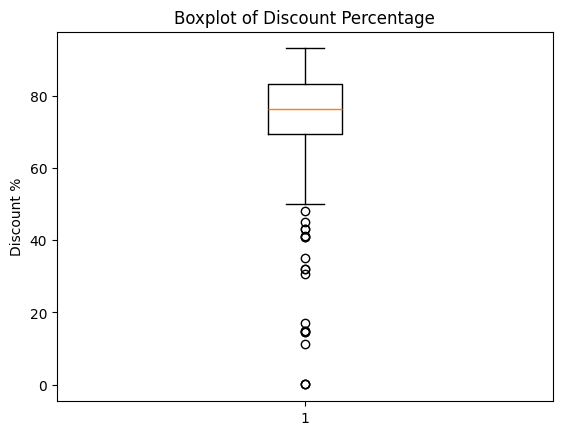

In [59]:
plt.figure()
plt.boxplot(df['discount_pct'])
plt.title("Boxplot of Discount Percentage")
plt.ylabel("Discount %")
plt.show()

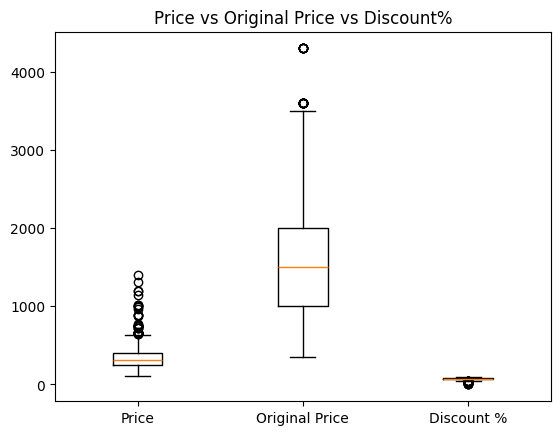

In [60]:
plt.figure()
plt.boxplot([df['price'], df['original_price'], df['discount_pct']])
plt.title("Price vs Original Price vs Discount%")
plt.xticks([1,2,3], ['Price','Original Price','Discount %'])
plt.show()

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
numeric_cols = ['price', 'original_price', 'discount_pct', 'savings', 'page']

In [63]:
corr_matrix = df[numeric_cols].corr()

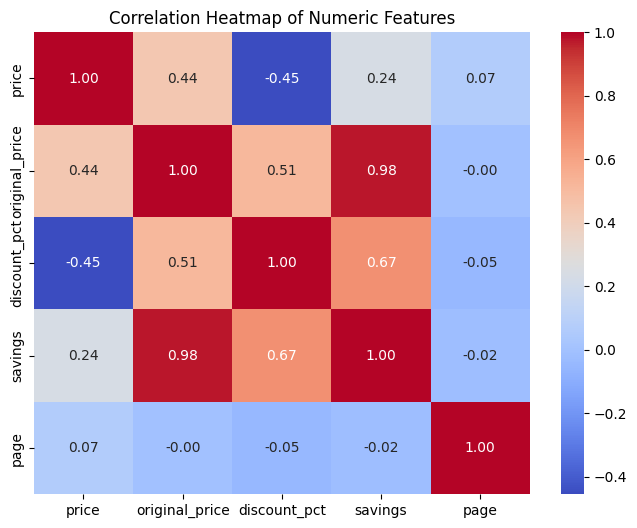

In [64]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

##### OUTPUT

### PHASE 4 : MACHINE LEARNING MODEL

##### • Recommendation -> Suggest similar items

In [65]:
features = ['name', 'company', 'price_band', 'discount_pct']
df_model = df[features].copy()

In [66]:
df_model['discount_pct'] = df_model['discount_pct'].astype(str)

In [67]:
df_model['combined_features'] = (
    df_model['name'] + " " +
    df_model['company'] + " " +
    df_model['price_band'] + " " +
    df_model['discount_pct']
)

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
feature_matrix = vectorizer.fit_transform(df_model['combined_features'])

In [69]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(feature_matrix)

In [70]:
def recommend(query, top_n=5):
    query = str(query).lower()
    
    # Search across multiple columns
    mask = (
        df['name'].astype(str).str.lower().str.contains(query) |
        df['company'].astype(str).str.lower().str.contains(query) |
        df['price'].astype(str).str.contains(query) |
        df['discount_pct'].astype(str).str.contains(query)
    )
    
    indices = df[mask].index
    
    if len(indices) == 0:
        return "Item not found!"
    
    idx = indices[0]
    
    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    product_indices = [i[0] for i in scores]
    
    return df[['name','company','price','discount_pct']].iloc[product_indices]


In [71]:
unique_price = df.price.unique()

In [72]:
df.price.unique()

array([ 298.,  338.,  459.,  306.,  192.,  285.,  210.,  237.,  266.,
        260.,  270.,  594.,  350.,  393.,  256.,  241.,  392.,  262.,
        416.,  318.,  226.,  252.,  220.,  446.,  998.,  322.,  243.,
        236.,  163.,  240.,  475.,  276.,  752.,  148.,  394.,  610.,
        267.,  234.,  431.,  313.,  219.,  328.,  235.,  263.,  337.,
        385.,  421.,  336.,  665.,  319.,  229.,  374.,  246.,  214.,
        211.,  289.,  212.,  255.,  265.,  420.,  282.,  367.,  250.,
        218.,  305.,  205.,  172.,  360.,  249.,  290.,  283.,  629.,
        295.,  291.,  280.,  442.,  457.,  277.,  507.,  608.,  354.,
        300.,  499.,  315.,  434.,  399.,  273.,  479.,  253.,  368.,
        180.,  232.,  228.,  120.,  248.,  330.,  329.,  391.,  452.,
        261.,  317.,  759.,  224.,  202.,  242.,  178.,  437.,  884.,
        175.,  279.,  372.,  388.,  436.,  308.,  207.,  450.,  410.,
        358.,  221.,  223.,  183.,  389.,  222.,  258.,  559.,  435.,
        662.,  440.,

In [73]:
df['discount_pct'].sort_values(ascending=False).unique()

array([9.309e+01, 9.048e+01, 9.040e+01, 8.989e+01, 8.974e+01, 8.949e+01,
       8.944e+01, 8.939e+01, 8.934e+01, 8.924e+01, 8.909e+01, 8.899e+01,
       8.885e+01, 8.884e+01, 8.881e+01, 8.879e+01, 8.874e+01, 8.870e+01,
       8.869e+01, 8.859e+01, 8.848e+01, 8.834e+01, 8.829e+01, 8.824e+01,
       8.821e+01, 8.819e+01, 8.804e+01, 8.799e+01, 8.794e+01, 8.784e+01,
       8.780e+01, 8.773e+01, 8.769e+01, 8.760e+01, 8.755e+01, 8.739e+01,
       8.737e+01, 8.734e+01, 8.733e+01, 8.699e+01, 8.674e+01, 8.672e+01,
       8.669e+01, 8.668e+01, 8.649e+01, 8.644e+01, 8.639e+01, 8.634e+01,
       8.630e+01, 8.627e+01, 8.619e+01, 8.610e+01, 8.609e+01, 8.599e+01,
       8.592e+01, 8.580e+01, 8.579e+01, 8.574e+01, 8.562e+01, 8.549e+01,
       8.532e+01, 8.526e+01, 8.523e+01, 8.519e+01, 8.510e+01, 8.509e+01,
       8.499e+01, 8.488e+01, 8.486e+01, 8.468e+01, 8.459e+01, 8.453e+01,
       8.448e+01, 8.446e+01, 8.437e+01, 8.432e+01, 8.431e+01, 8.418e+01,
       8.409e+01, 8.407e+01, 8.406e+01, 8.405e+01, 

In [74]:
recommend("Men Regular Fit Checkered Button Down Collar C")

,name,company,price,discount_pct
834,Men Regular Fit Checkered Button Down Collar C...,RED TAPE,610.0,81.51
34,Men Regular Fit Solid Button Down Collar Casua...,RED TAPE,752.0,82.51
157,Men Regular Fit Solid Button Down Collar Casua...,RED TAPE,752.0,82.51
197,Men Regular Fit Solid Button Down Collar Casua...,RED TAPE,752.0,82.51
437,Men Regular Fit Solid Button Down Collar Casua...,RED TAPE,752.0,82.51


In [75]:
recommend("319")

,name,company,price,discount_pct
122,Men Regular Fit Solid Spread Collar Casual Shirt,METRONAUT PLUS,457.0,83.07
592,Men Solid Round Neck Cotton Blend Black T-Shirt,BLIVE,223.0,77.68
99,Men Printed Round Neck Pure Cotton Multicolor ...,Magneto,305.0,66.07
139,Men Printed Round Neck Pure Cotton Multicolor ...,Magneto,305.0,66.07
942,Men Printed Round Neck Pure Cotton Multicolor ...,Magneto,309.0,69.07


In [76]:
recommend("7.9")

,name,company,price,discount_pct
136,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94
177,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94
417,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94
776,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94
814,Men Solid Mandarin Collar Cotton Blend Maroon ...,TRIPR,241.0,87.94


In [77]:
recommend("Try This")

,name,company,price,discount_pct
95,Men Striped Zip Neck Cotton Blend Brown T-Shirt,Try This,306.0,69.37
838,"Men Checkered Zip Neck Cotton Blend White, Bla...",Try This,285.0,71.47
919,Men Colorblock Zip Neck Cotton Blend Black T-S...,Try This,240.0,75.98
855,Men Striped Zip Neck Cotton Blend Brown T-Shirt,Try This,287.0,71.27
449,Men Checkered Zip Neck Cotton Blend Dark Green...,Try This,287.0,71.27


In [78]:
df.company.unique()

<ArrowStringArray>
[                   'KAJARU',                     'TRIPR',
                  'Try This',                     'Surhi',
                    'VeBNoR',                   'N AND J',
                 'JACKBELLA',                     'DIMMY',
                   'Raymond',                     'WOXEN',
 ...
                 'Southcity',               'Tee Gallery',
                      'DBAX',                   'GLAUCUS',
 'United Colors of Benetton',                'BLUE SQUAD',
                'PrintHolic',                 'Lux Nitro',
                'hkCreation',                 'BlueFicus']
Length: 190, dtype: str

## Train–Test Split -> Model Training -> Evaluation (Accuracy/RMSE/R²)

In [79]:
from sklearn.model_selection import train_test_split

X = df[['original_price', 'discount_pct', 'company', 'page']]
y = df['price']

In [80]:
X = pd.get_dummies(X, columns=['company'], drop_first=True)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [82]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [83]:
y_pred = model.predict(X_test)

In [84]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 29.968378939548487
R² Score: 0.9339899426650998


C:\Users\TRIDEV PAL\Downloads\anacondajupiter\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [108]:
train_score = model.score(X_train, y_train)
print("Training Score:", train_score)

Training Score: 0.9632903094507861


In [109]:
test_score = model.score(X_test, y_test)
print("Testing Score:", test_score)

Testing Score: 0.9339899426650998


In [85]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,459.0,399.856464
1,392.0,387.401691
2,393.0,394.705391
3,393.0,394.165069
4,393.0,392.544103
5,382.0,316.031325
6,475.0,473.591820
7,276.0,361.583190
8,279.0,282.668245
9,241.0,270.102677


In [86]:
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 29.968378939548487
R² Score: 0.9339899426650998


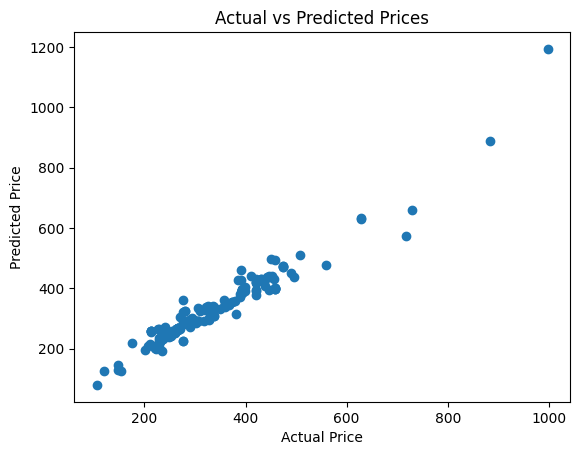

In [87]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

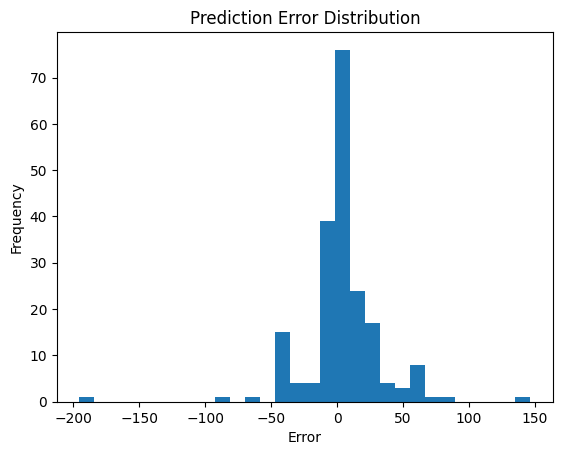

In [88]:
errors = y_test - y_pred

plt.figure()
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [89]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients.head(10)

,Feature,Coefficient
172,company_WROGN,348.203592
152,company_U.S. POLO ASSN.,301.046858
116,company_Raymond,210.876294
128,company_Snitch,195.550954
160,company_VAN HEUSEN,164.548595
77,company_LOUIS PHILIPPE,144.210243
136,company_THE BEAR HOUSE,137.952556
16,company_Allen Cooper,133.468903
53,company_HERE&NOW,129.247473
99,company_PARK AVENUE,122.303218


In [90]:
# The high R² score indicates strong linear dependency between price
# and features such as original price and discount, which is expected in pricing models.

In [91]:
df.head()

,name,company,price,original_price,discount,offers,url,page,discount_pct,savings,price_band,high_discount
0,Men Solid Zip Neck Cotton Blend Black T-Shirt,KAJARU,298.0,999.0,70.0,Hot Deal,https://www.flipkart.com/kajaru-solid-men-zip-...,1,70.17,701.0,Budget,1
1,"Men Printed Polo Neck Cotton Blend Black, Grey...",TRIPR,338.0,999.0,66.0,"Buy 2 items, save extra 5%",https://www.flipkart.com/tripr-printed-men-pol...,1,66.17,661.0,Budget,1
2,Pack of 4 Men Solid Round Neck Cotton Blend Mu...,TRIPR,459.0,1999.0,77.0,"Buy 2 items, save extra 5%",https://www.flipkart.com/tripr-solid-men-round...,1,77.04,1540.0,Budget,1
3,"Men Striped Zip Neck Cotton Blend Black, White...",Try This,306.0,999.0,69.0,Only few left,https://www.flipkart.com/try-striped-men-zip-n...,1,69.37,693.0,Budget,1
4,Men Solid Henley Neck Cotton Blend Black T-Shirt,TRIPR,192.0,1999.0,90.0,Hot Deal,https://www.flipkart.com/tripr-solid-men-henle...,1,90.40,1807.0,Budget,1


In [92]:
df.high_discount.to_csv("df.high_discount.csv",index=False)

In [93]:
df.discount_pct.to_csv('df.discount_pct.csv',index=False)

In [94]:
df.price_band.to_csv('df.df.price_band.csv',index=False)

In [95]:
df.savings.to_csv('df.savings.csv',index=False)

In [96]:
company_savings.to_csv('company_savings.csv')

In [97]:
company_discount_pact.to_csv('df.company_discount_pact.csv',index=False)

In [98]:
pd.DataFrame(unique_price).to_csv('unique_price.csv')

In [99]:
results.to_csv('results.csv', index=False)

In [100]:
coefficients.to_csv("coefficients.csv", index=False)

In [101]:
df.to_csv("df.csv",index=False)